<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
SalimosHoy? - Ejecucion y comparacion de modelos
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se preparara el notebook tecnico que deja evidencia ejecutada del modelado de SalimosHoy?. Aqui se cargan datos, se valida el EDA, se entrenan modelos y se justifica el modelo ligero usado en la app final. No se guardaran CSVs ni modelos nuevos porque <span style="color:#D11A2A; font-weight:700;">SAVE_ARTIFACTS</span> queda desactivado.
  </p>
</div>

In [ ]:
from pathlib import Path
import warnings
import time
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from google.colab import drive # type: ignore
drive.mount('/content/drive')
!find /content/drive/MyDrive -maxdepth 5 -type d -name "SalimosHoy_Modelado_Final"
%cd /content/drive/MyDrive/Colab_Notebooks/SalimosHoy_Modelado_Final

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Notebooks/SalimosHoy_Modelado_Final
/content/drive/MyDrive/Colab_Notebooks/SalimosHoy_Modelado_Final


In [2]:
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
SAVE_ARTIFACTS = False

if Path("datasets").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "datasets" / "salimoshoy_full_dataset.csv"

TARGET_COLUMN = "recommendation"

NUMERIC_FEATURES = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation_probability",
    "wind_speed_10m",
    "wind_gusts_10m",
    "cloud_cover",
    "uv_index",
    "hour",
]

CATEGORICAL_FEATURES = [
    "activity",
    "continent",
    "climate_group",
    "season_block",
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
CLASS_ORDER = ["malo", "regular", "bueno", "excelente"]

print("Carpeta raiz:", PROJECT_ROOT)
print("Dataset:", DATASET_PATH)
print("Existe dataset:", DATASET_PATH.exists())
print("Guardar archivos:", SAVE_ARTIFACTS)

Carpeta raiz: /content/drive/MyDrive/Colab_Notebooks/SalimosHoy_Modelado_Final
Dataset: /content/drive/MyDrive/Colab_Notebooks/SalimosHoy_Modelado_Final/datasets/salimoshoy_full_dataset.csv
Existe dataset: True
Guardar archivos: False


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Estilo visual de tablas
</h2>

In [ ]:
def style_table(styler):
    return (
        styler
        .set_table_styles(
            [
                {
                    "selector": "thead th",
                    "props": [
                        ("background-color", "#0f172a"),
                        ("color", "white"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                        ("border", "1px solid #334155"),
                        ("padding", "8px"),
                    ],
                },
                {
                    "selector": "tbody td",
                    "props": [
                        ("border", "1px solid #cbd5e1"),
                        ("padding", "8px"),
                        ("text-align", "center"),
                    ],
                },
                {
                    "selector": "tbody th",
                    "props": [
                        ("border", "1px solid #cbd5e1"),
                        ("padding", "8px"),
                        ("text-align", "center"),
                        ("background-color", "#f1f5f9"),
                    ],
                },
                {
                    "selector": "tbody tr:nth-child(even)",
                    "props": [("background-color", "#f8fafc")],
                },
                {
                    "selector": "tbody tr:nth-child(odd)",
                    "props": [("background-color", "#ffffff")],
                },
            ]
        )
        .set_properties(**{"font-size": "14px", "color": "#111827"})
    )

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El estilo de tablas queda configurado correctamente. Todas las salidas tabulares del notebook usaran el mismo formato visual para mantener una presentacion limpia y consistente.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Llamado a las APIs usadas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se hara un llamado de prueba a las APIs de Open-Meteo. La validacion confirma si la busqueda de ciudad, el clima actualizado y el clima historico entregan respuestas utiles para el proyecto.
  </p>
</div>

In [32]:
# APIs usadas en el proyecto
GEOCODING_URL = "https://geocoding-api.open-meteo.com/v1/search"
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"
HISTORICAL_URL = "https://archive-api.open-meteo.com/v1/archive"

api_results = []

# 1. Geocoding API: convierte una ciudad en coordenadas
geocoding_params = {
    "name": "Madrid",
    "count": 1,
    "language": "es",
    "format": "json",
}

geocoding_response = requests.get(GEOCODING_URL, params=geocoding_params, timeout=20)
geocoding_data = geocoding_response.json()

city_info = geocoding_data["results"][0]

latitude = city_info["latitude"]
longitude = city_info["longitude"]
timezone = city_info["timezone"]

api_results.append({
    "api": "Open-Meteo Geocoding API",
    "uso": "Buscar ciudad y obtener coordenadas",
    "status_code": geocoding_response.status_code,
    "resultado": f"{city_info['name']}, {city_info.get('country', '')}",
})

# 2. Forecast API: consulta clima actualizado
forecast_params = {
    "latitude": latitude,
    "longitude": longitude,
    "timezone": timezone,
    "forecast_days": 1,
    "hourly": ",".join([
        "temperature_2m",
        "apparent_temperature",
        "relative_humidity_2m",
        "precipitation_probability",
        "wind_speed_10m",
        "wind_gusts_10m",
        "cloud_cover",
        "uv_index",
    ]),
}

forecast_response = requests.get(FORECAST_URL, params=forecast_params, timeout=20)
forecast_data = forecast_response.json()

api_results.append({
    "api": "Open-Meteo Forecast API",
    "uso": "Consultar clima actualizado por hora",
    "status_code": forecast_response.status_code,
    "resultado": f"{len(forecast_data['hourly']['time'])} horas recibidas",
})

# 3. Historical API: consulta clima historico usado para construir el dataset
historical_params = {
    "latitude": latitude,
    "longitude": longitude,
    "timezone": timezone,
    "start_date": "2025-01-01",
    "end_date": "2025-01-02",
    "hourly": ",".join([
        "temperature_2m",
        "apparent_temperature",
        "relative_humidity_2m",
        "precipitation",
        "wind_speed_10m",
        "wind_gusts_10m",
        "cloud_cover",
        "shortwave_radiation",
    ]),
}

historical_response = requests.get(HISTORICAL_URL, params=historical_params, timeout=20)
historical_data = historical_response.json()

api_results.append({
    "api": "Open-Meteo Historical API",
    "uso": "Consultar clima historico para crear dataset",
    "status_code": historical_response.status_code,
    "resultado": f"{len(historical_data['hourly']['time'])} horas historicas recibidas",
})

api_results_df = pd.DataFrame(api_results)

display(
    style_table(
        api_results_df.style.hide(axis="index")
    )
)

print("Ciudad usada como ejemplo:")
print(city_info["name"], city_info.get("country", ""))

print("\nCoordenadas:")
print("latitud:", latitude)
print("longitud:", longitude)
print("timezone:", timezone)

print("\nVariables recibidas desde Forecast API:")
print(list(forecast_data["hourly"].keys()))

print("\nVariables recibidas desde Historical API:")
print(list(historical_data["hourly"].keys()))

api,uso,status_code,resultado
Open-Meteo Geocoding API,Buscar ciudad y obtener coordenadas,200,"Madrid, España"
Open-Meteo Forecast API,Consultar clima actualizado por hora,200,24 horas recibidas
Open-Meteo Historical API,Consultar clima historico para crear dataset,200,48 horas historicas recibidas


Ciudad usada como ejemplo:
Madrid España

Coordenadas:
latitud: 40.4165
longitud: -3.70256
timezone: Europe/Madrid

Variables recibidas desde Forecast API:
['time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation_probability', 'wind_speed_10m', 'wind_gusts_10m', 'cloud_cover', 'uv_index']

Variables recibidas desde Historical API:
['time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_gusts_10m', 'cloud_cover', 'shortwave_radiation']


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Las tres APIs respondieron correctamente con codigo 200. Geocoding devolvio Madrid con sus coordenadas, Forecast entrego 24 horas de clima actualizado y Historical entrego 48 horas historicas. Esto confirma que Open-Meteo sirve como fuente de datos para la app y para la construccion del dataset.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Glosario de terminos del proyecto
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se presenta un glosario breve para que cualquier persona pueda entender las variables, metricas y conceptos usados en el proyecto.
  </p>
</div>

In [33]:
glosario = pd.DataFrame([
    {
        "termino": "SalimosHoy?",
        "significado": "Nombre de la aplicacion. Recomienda si conviene realizar una actividad segun el clima."
    },
    {
        "termino": "Open-Meteo",
        "significado": "API usada para obtener datos climaticos actuales e historicos."
    },
    {
        "termino": "API",
        "significado": "Servicio que permite pedir datos a otra plataforma desde Python o desde la app."
    },
    {
        "termino": "Geocoding",
        "significado": "Proceso para convertir el nombre de una ciudad en latitud, longitud y zona horaria."
    },
    {
        "termino": "Forecast",
        "significado": "Pronostico o datos climaticos actuales/futuros usados por la app."
    },
    {
        "termino": "Historical API",
        "significado": "API historica usada para crear el dataset de entrenamiento con datos pasados."
    },
    {
        "termino": "Dataset",
        "significado": "Tabla de datos usada para analizar informacion y entrenar modelos."
    },
    {
        "termino": "Registro",
        "significado": "Una fila del dataset. En este proyecto representa una hora, una ciudad, una actividad y sus condiciones climaticas."
    },
    {
        "termino": "Feature",
        "significado": "Variable que usa el modelo para aprender. Por ejemplo temperatura, humedad, viento, actividad o grupo climatico."
    },
    {
        "termino": "Target",
        "significado": "Variable que el modelo intenta predecir. En este proyecto es recommendation."
    },
    {
        "termino": "recommendation",
        "significado": "Etiqueta objetivo del modelo. Puede ser malo, regular, bueno o excelente."
    },
    {
        "termino": "recommendation_final",
        "significado": "Resultado final mostrado por la app despues de combinar el modelo con reglas de seguridad climatica."
    },
    {
        "termino": "activity_score",
        "significado": "Puntuacion interna que mide que tan buenas son las condiciones para una actividad."
    },
    {
        "termino": "comfort_distance",
        "significado": "Medida de que tan lejos estan las condiciones reales de las condiciones ideales de una actividad."
    },
    {
        "termino": "temperature_2m",
        "significado": "Temperatura del aire a 2 metros de altura."
    },
    {
        "termino": "apparent_temperature",
        "significado": "Sensacion termica. Representa como se siente la temperatura para una persona."
    },
    {
        "termino": "relative_humidity_2m",
        "significado": "Humedad relativa del aire. Puede afectar la sensacion de calor o incomodidad."
    },
    {
        "termino": "precipitation_probability",
        "significado": "Probabilidad de lluvia o precipitacion."
    },
    {
        "termino": "wind_speed_10m",
        "significado": "Velocidad del viento a 10 metros de altura."
    },
    {
        "termino": "wind_gusts_10m",
        "significado": "Rachas de viento. Ayuda a detectar momentos con viento mas fuerte."
    },
    {
        "termino": "cloud_cover",
        "significado": "Porcentaje de nubosidad."
    },
    {
        "termino": "uv_index",
        "significado": "Indice UV. Mide la intensidad de radiacion solar."
    },
    {
        "termino": "season_block",
        "significado": "Mes estrategico usado para representar distintas epocas del año."
    },
    {
        "termino": "climate_group",
        "significado": "Grupo climatico de la ciudad. Ejemplo: frio_fuerte, calor_seco, tropical_humedo."
    },
    {
        "termino": "Modelo ML",
        "significado": "Modelo de Machine Learning que aprende a clasificar las condiciones climaticas para una actividad."
    },
    {
        "termino": "RandomForestClassifier",
        "significado": "Modelo basado en muchos arboles de decision. Fue el tipo de modelo elegido para la app final."
    },
    {
        "termino": "DecisionTreeClassifier",
        "significado": "Modelo basado en un solo arbol de decision. Se uso como modelo base de comparacion."
    },
    {
        "termino": "ExtraTreesClassifier",
        "significado": "Modelo parecido a RandomForest, usado como comparacion adicional."
    },
    {
        "termino": "Accuracy",
        "significado": "Porcentaje general de aciertos del modelo."
    },
    {
        "termino": "Recall",
        "significado": "Capacidad del modelo para detectar correctamente una clase concreta."
    },
    {
        "termino": "Recall malo",
        "significado": "Mide que tan bien detecta el modelo las condiciones malas. Es importante para evitar recomendaciones peligrosas."
    },
    {
        "termino": "Recall regular",
        "significado": "Mide que tan bien detecta el modelo condiciones intermedias."
    },
    {
        "termino": "Matriz de confusion",
        "significado": "Tabla que muestra aciertos y errores del modelo por clase."
    },
    {
        "termino": "Train",
        "significado": "Parte del dataset usada para entrenar el modelo."
    },
    {
        "termino": "Test",
        "significado": "Parte del dataset usada para evaluar si el modelo funciona con datos que no vio durante el entrenamiento."
    },
    {
        "termino": "Muestra estratificada",
        "significado": "Muestra que mantiene la misma proporcion de clases que el dataset original."
    },
    {
        "termino": "Pipeline",
        "significado": "Flujo que une el preprocesamiento y el modelo para aplicar siempre los mismos pasos."
    },
    {
        "termino": "OneHotEncoder",
        "significado": "Tecnica para convertir variables categoricas en columnas numericas que el modelo pueda usar."
    },
    {
        "termino": "StandardScaler",
        "significado": "Tecnica para escalar variables numericas y dejarlas en rangos comparables."
    },
    {
        "termino": "Reglas de seguridad",
        "significado": "Reglas finales que evitan recomendaciones poco realistas cuando hay lluvia fuerte, viento alto o temperaturas extremas."
    },
    {
        "termino": "Modelo ligero",
        "significado": "Modelo optimizado para GitHub/demo. Mantiene buen rendimiento y pesa menos que los modelos grandes."
    },
])

display(
    style_table(
        glosario.style.hide(axis="index")
    )
)

termino,significado
SalimosHoy?,Nombre de la aplicacion. Recomienda si conviene realizar una actividad segun el clima.
Open-Meteo,API usada para obtener datos climaticos actuales e historicos.
API,Servicio que permite pedir datos a otra plataforma desde Python o desde la app.
Geocoding,"Proceso para convertir el nombre de una ciudad en latitud, longitud y zona horaria."
Forecast,Pronostico o datos climaticos actuales/futuros usados por la app.
Historical API,API historica usada para crear el dataset de entrenamiento con datos pasados.
Dataset,Tabla de datos usada para analizar informacion y entrenar modelos.
Registro,"Una fila del dataset. En este proyecto representa una hora, una ciudad, una actividad y sus condiciones climaticas."
Feature,"Variable que usa el modelo para aprender. Por ejemplo temperatura, humedad, viento, actividad o grupo climatico."
Target,Variable que el modelo intenta predecir. En este proyecto es recommendation.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El glosario deja claros los conceptos principales: API, dataset, features, target, recommendation, score, metricas y modelo. Esto facilita la lectura del notebook para personas sin experiencia tecnica.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Carga del dataset final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se cargara el dataset final consolidado de SalimosHoy?. Este archivo es la base usada para el EDA y para entrenar los modelos comparados en este notebook.
  </p>
</div>

In [4]:
df = pd.read_csv(DATASET_PATH)

resumen_dataset = pd.DataFrame({
    "descripcion": ["Filas", "Columnas"],
    "valor": [f"{df.shape[0]:,}", df.shape[1]]
})

columnas_dataset = pd.DataFrame({
    "numero": range(1, len(df.columns) + 1),
    "columna": df.columns,
    "tipo_dato": df.dtypes.astype(str).values
})

print("Resumen del dataset:")
display(
    style_table(
        resumen_dataset.style.hide(axis="index")
    )
)

print("\nColumnas del dataset:")
display(
    style_table(
        columnas_dataset.style.hide(axis="index")
    )
)

Resumen del dataset:


descripcion,valor
Filas,"3,054,400"
Columnas,22



Columnas del dataset:


numero,columna,tipo_dato
1,time,object
2,temperature_2m,float64
3,apparent_temperature,float64
4,relative_humidity_2m,int64
5,precipitation_probability,float64
6,wind_speed_10m,float64
7,wind_gusts_10m,float64
8,cloud_cover,int64
9,uv_index,float64
10,hour,int64


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El dataset se cargo correctamente con <span style="color:#D11A2A; font-weight:700;">3,054,400 filas</span> y <span style="color:#D11A2A; font-weight:700;">22 columnas</span> usando como base 200 ciudades y seis meses de datos historicos metereologicos. La estructura contiene variables climaticas, datos de ciudad, actividad, score interno y la etiqueta recommendation.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Primeras 10 filas del dataset
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se mostraran las primeras 10 filas con todas las columnas principales. Esto permite revisar visualmente como esta construida cada observacion antes de iniciar el analisis.
  </p>
</div>

In [5]:
primeras_filas = df.head(10).copy()

primeras_filas_transpuesta = (
    primeras_filas
    .T
    .reset_index()
    .rename(columns={"index": "columna"})
)

primeras_filas_transpuesta.columns = ["columna"] + [
    f"fila_{i + 1}" for i in range(10)
]

display(
    style_table(
        primeras_filas_transpuesta.style.hide(axis="index")
    )
)

columna,fila_1,fila_2,fila_3,fila_4,fila_5,fila_6,fila_7,fila_8,fila_9,fila_10
time,2025-01-01 07:00:00,2025-01-01 08:00:00,2025-01-01 09:00:00,2025-01-01 10:00:00,2025-01-01 11:00:00,2025-01-01 12:00:00,2025-01-01 13:00:00,2025-01-01 14:00:00,2025-01-01 15:00:00,2025-01-01 16:00:00
temperature_2m,-0.900000,-0.300000,0.700000,1.400000,2.300000,3.000000,4.200000,5.200000,7.200000,7.800000
apparent_temperature,-3.500000,-2.700000,-1.700000,-1.000000,-0.200000,0.800000,2.200000,3.400000,5.400000,6.000000
relative_humidity_2m,91,90,89,91,92,94,90,85,76,74
precipitation_probability,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
wind_speed_10m,1.100000,0.200000,0.900000,2.300000,3.600000,3.200000,2.000000,1.700000,1.600000,1.700000
wind_gusts_10m,4.000000,3.600000,1.800000,4.300000,7.900000,10.400000,11.500000,10.800000,10.800000,11.900000
cloud_cover,100,100,100,100,100,100,100,100,13,1
uv_index,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hour,7,8,9,10,11,12,13,14,15,16


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La vista inicial confirma que cada registro representa una hora especifica, una ciudad, una actividad y sus condiciones climaticas. Tambien aparecen variables de contexto como continente, grupo climatico, season_block, activity_score, comfort_distance y recommendation.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Revision de nulos y tipos de datos
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se revisaran valores nulos y tipos de datos. Esta validacion evita entrenar modelos con columnas incompletas o tipos inconsistentes.
  </p>
</div>

In [6]:
revision_columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "porcentaje_nulos": (df.isna().mean().values * 100).round(2)
})

resumen_nulos = pd.DataFrame({
    "revision": ["Total de nulos", "Columnas con nulos"],
    "resultado": [
        int(df.isna().sum().sum()),
        int((df.isna().sum() > 0).sum())
    ]
})

print("Resumen de nulos:")
display(
    style_table(
        resumen_nulos.style.hide(axis="index")
    )
)

print("\nRevision por columna:")
display(
    style_table(
        revision_columnas.style.hide(axis="index")
    )
)

Resumen de nulos:


revision,resultado
Total de nulos,0
Columnas con nulos,0



Revision por columna:


columna,tipo_dato,nulos,porcentaje_nulos
time,object,0,0.000000
temperature_2m,float64,0,0.000000
apparent_temperature,float64,0,0.000000
relative_humidity_2m,int64,0,0.000000
precipitation_probability,float64,0,0.000000
wind_speed_10m,float64,0,0.000000
wind_gusts_10m,float64,0,0.000000
cloud_cover,int64,0,0.000000
uv_index,float64,0,0.000000
hour,int64,0,0.000000


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se confirma que el dataset tiene <span style="color:#D11A2A; font-weight:700;">0 valores nulos</span> y <span style="color:#D11A2A; font-weight:700;">0 columnas con nulos</span>. Los tipos de datos quedan listos para separar variables numericas y categoricas antes del entrenamiento.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Distribucion global de recommendation
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se revisara la variable objetivo recommendation. El objetivo es confirmar que las clases malo, regular, bueno y excelente tienen representacion suficiente antes del entrenamiento.
  </p>
</div>

Distribucion global de recommendation:


recommendation,count,percentage
excelente,1457559,47.720000
bueno,846349,27.710000
regular,495985,16.240000
malo,254507,8.330000


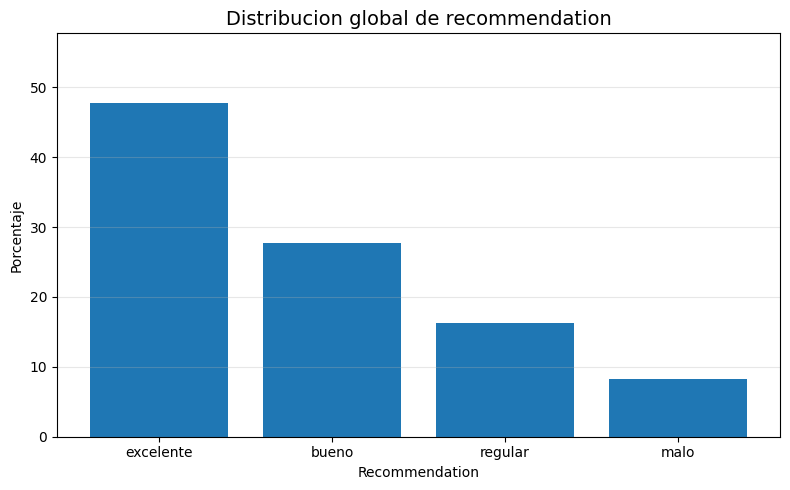

In [7]:
recommendation_distribution = (
    df["recommendation"]
    .value_counts()
    .rename_axis("recommendation")
    .reset_index(name="count")
)

recommendation_distribution["percentage"] = (
    recommendation_distribution["count"] / len(df) * 100
).round(2)

print("Distribucion global de recommendation:")
display(
    style_table(
        recommendation_distribution.style.hide(axis="index")
    )
)

plt.figure(figsize=(8, 5))
plt.bar(
    recommendation_distribution["recommendation"],
    recommendation_distribution["percentage"]
)

plt.title("Distribucion global de recommendation", fontsize=14)
plt.xlabel("Recommendation")
plt.ylabel("Porcentaje")
plt.ylim(0, recommendation_distribution["percentage"].max() + 10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La clase mas frecuente es <span style="color:#D11A2A; font-weight:700;">excelente</span> con 47.72%, seguida de bueno con 27.71%, regular con 16.24% y malo con 8.33%. Las clases malo y regular no quedan desaparecidas, por lo que el modelo puede aprender tambien condiciones poco favorables.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Distribucion de recommendation por actividad
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se analizara la distribucion de recommendation por actividad. Esto permite comprobar si actividades exteriores e interiores se comportan de forma diferente frente al clima.
  </p>
</div>

Distribucion porcentual de recommendation por actividad:


activity,malo,regular,bueno,excelente
Deportes al aire libre,13.05%,24.11%,41.30%,21.54%
Ir a la playa,13.75%,37.08%,23.92%,25.25%
Ir al cine,0.00%,0.00%,4.10%,95.90%
Jardineria y agricultura,7.77%,18.50%,26.04%,47.69%
Pasear o hacer senderismo,7.49%,8.38%,36.76%,47.38%
Picnic o actividades en parque,7.56%,9.49%,31.73%,51.21%


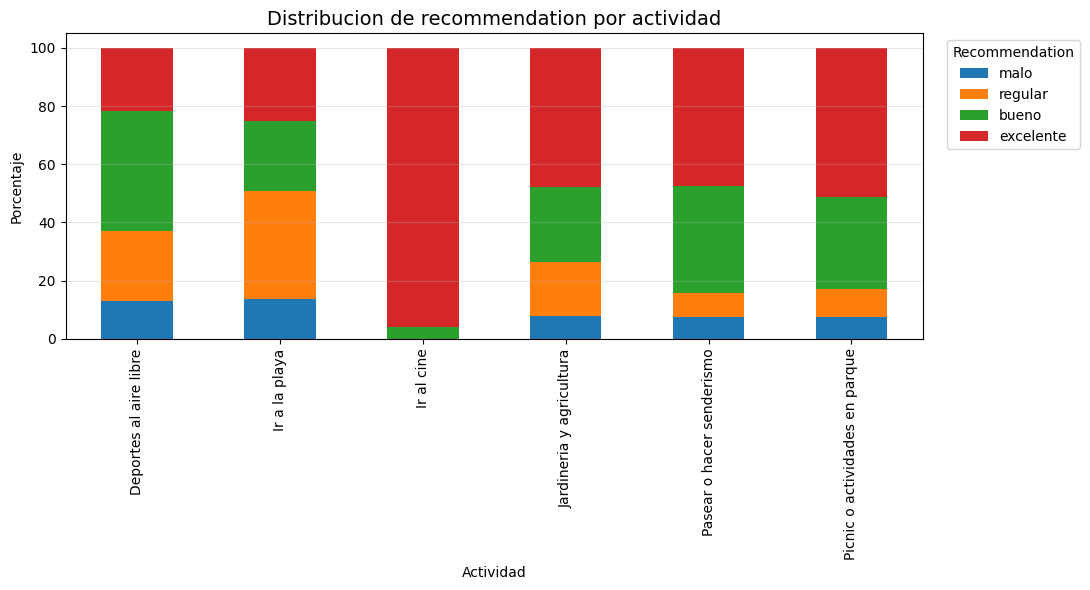

In [8]:
activity_distribution = (
    df.groupby(["activity", "recommendation"])
    .size()
    .reset_index(name="count")
)

activity_totals = (
    activity_distribution
    .groupby("activity")["count"]
    .transform("sum")
)

activity_distribution["percentage"] = (
    activity_distribution["count"] / activity_totals * 100
).round(2)

activity_pivot = (
    activity_distribution
    .pivot_table(
        index="activity",
        columns="recommendation",
        values="percentage",
        fill_value=0
    )
    .reset_index()
)

activity_pivot = activity_pivot[["activity", "malo", "regular", "bueno", "excelente"]]

print("Distribucion porcentual de recommendation por actividad:")
display(
    style_table(
        activity_pivot.style.hide(axis="index").format({
            "malo": "{:.2f}%",
            "regular": "{:.2f}%",
            "bueno": "{:.2f}%",
            "excelente": "{:.2f}%"
        })
    )
)

activity_pivot_plot = activity_pivot.set_index("activity")[["malo", "regular", "bueno", "excelente"]]

activity_pivot_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Distribucion de recommendation por actividad", fontsize=14)
plt.xlabel("Actividad")
plt.ylabel("Porcentaje")
plt.legend(title="Recommendation", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se observa una diferencia clara por actividad. Ir al cine concentra 95.90% de casos excelentes porque es una actividad interior. Ir a la playa y Deportes al aire libre presentan mas casos malos o regulares, lo cual es coherente con su mayor exposicion al clima.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Distribucion de recommendation por grupo climatico
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se revisara la distribucion de recommendation por grupo climatico. Esta validacion comprueba si el dataset captura diferencias entre climas frios, secos, humedos, tropicales y templados.
  </p>
</div>

Distribucion porcentual de recommendation por grupo climatico:


climate_group,malo,regular,bueno,excelente
calor_seco,9.68%,11.79%,30.99%,47.54%
frio_fuerte,27.31%,21.79%,22.14%,28.75%
hemisferio_sur,1.07%,13.25%,28.89%,56.79%
lluvia_humedad,3.73%,19.39%,29.11%,47.77%
templado_urbano,8.40%,22.28%,27.25%,42.06%
tropical_humedo,0.02%,8.83%,27.85%,63.30%


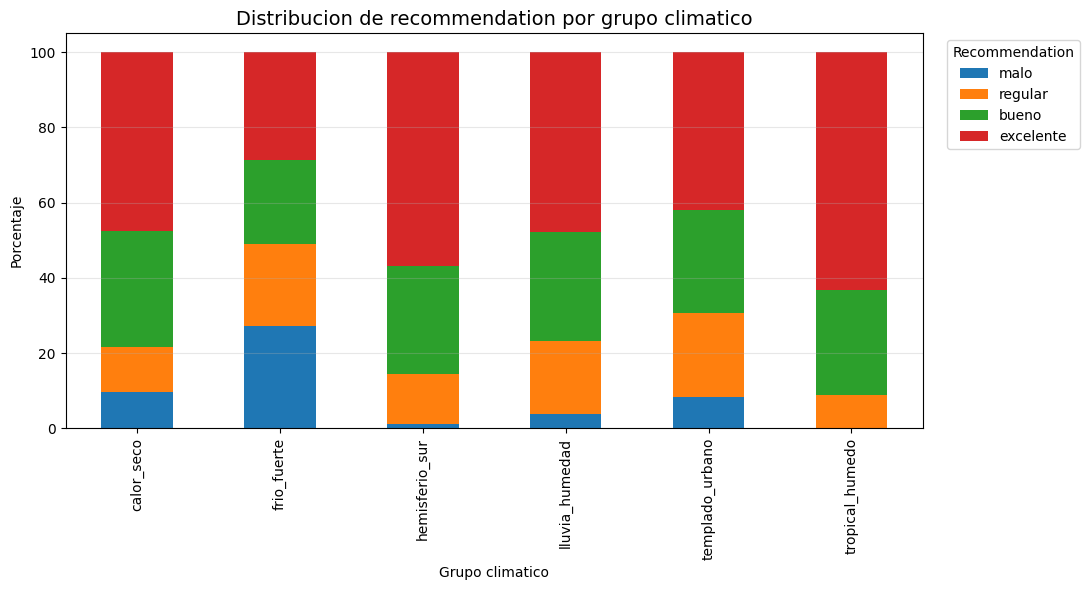

In [9]:
climate_distribution = (
    df.groupby(["climate_group", "recommendation"])
    .size()
    .reset_index(name="count")
)

climate_totals = (
    climate_distribution
    .groupby("climate_group")["count"]
    .transform("sum")
)

climate_distribution["percentage"] = (
    climate_distribution["count"] / climate_totals * 100
).round(2)

climate_pivot = (
    climate_distribution
    .pivot_table(
        index="climate_group",
        columns="recommendation",
        values="percentage",
        fill_value=0
    )
    .reset_index()
)

climate_pivot = climate_pivot.reindex(
    columns=["climate_group", "malo", "regular", "bueno", "excelente"],
    fill_value=0
)

print("Distribucion porcentual de recommendation por grupo climatico:")
display(
    style_table(
        climate_pivot.style.hide(axis="index").format({
            "malo": "{:.2f}%",
            "regular": "{:.2f}%",
            "bueno": "{:.2f}%",
            "excelente": "{:.2f}%"
        })
    )
)

climate_pivot_plot = climate_pivot.set_index("climate_group")[["malo", "regular", "bueno", "excelente"]]

climate_pivot_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Distribucion de recommendation por grupo climatico", fontsize=14)
plt.xlabel("Grupo climatico")
plt.ylabel("Porcentaje")
plt.legend(title="Recommendation", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El grupo frio_fuerte aporta la mayor proporcion de casos malos, con 27.31%. Tropical_humedo concentra 63.30% de casos excelentes y casi no tiene clase malo. Esto confirma que los grupos climaticos agregan variedad real al dataset.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Distribucion de recommendation por mes estrategico
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se revisara la variable season_block. El objetivo es validar si los meses estrategicos agregan variedad temporal al dataset.
  </p>
</div>

Distribucion porcentual de recommendation por mes estrategico:


season_block,malo,regular,bueno,excelente
enero,18.62%,17.71%,22.42%,41.26%
marzo,9.40%,18.90%,27.80%,43.89%
mayo,3.54%,15.83%,31.02%,49.61%
julio,4.77%,11.92%,29.08%,54.23%
septiembre,2.80%,13.90%,30.70%,52.59%
noviembre,10.76%,19.19%,25.25%,44.80%


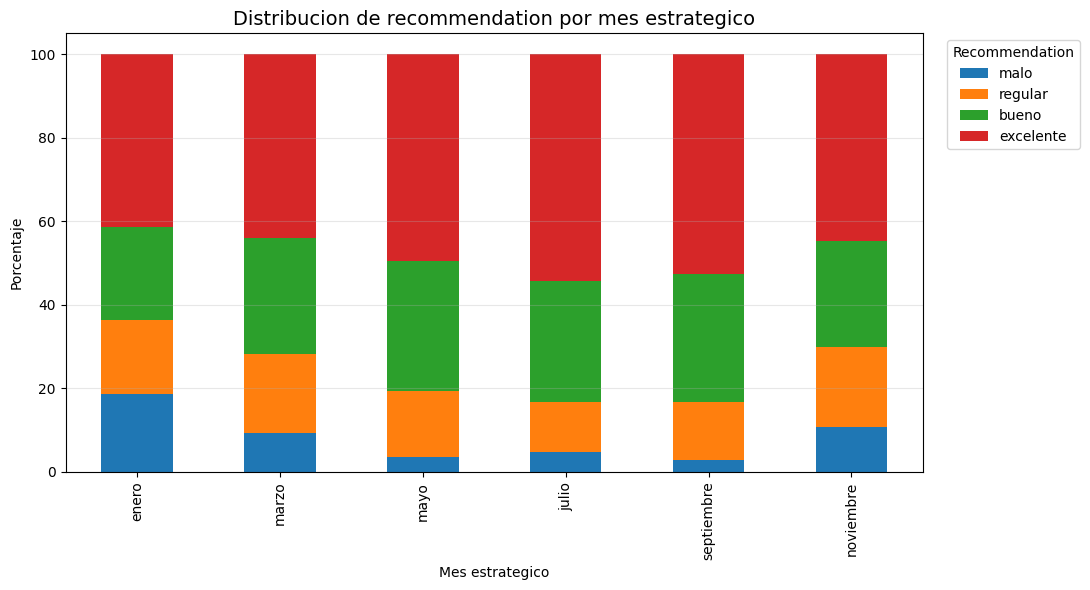

In [10]:
season_distribution = (
    df.groupby(["season_block", "recommendation"])
    .size()
    .reset_index(name="count")
)

season_totals = (
    season_distribution
    .groupby("season_block")["count"]
    .transform("sum")
)

season_distribution["percentage"] = (
    season_distribution["count"] / season_totals * 100
).round(2)

season_order = ["enero", "marzo", "mayo", "julio", "septiembre", "noviembre"]

season_pivot = (
    season_distribution
    .pivot_table(
        index="season_block",
        columns="recommendation",
        values="percentage",
        fill_value=0
    )
    .reindex(season_order)
    .reset_index()
)

season_pivot = season_pivot.reindex(
    columns=["season_block", "malo", "regular", "bueno", "excelente"],
    fill_value=0
)

print("Distribucion porcentual de recommendation por mes estrategico:")
display(
    style_table(
        season_pivot.style.hide(axis="index").format({
            "malo": "{:.2f}%",
            "regular": "{:.2f}%",
            "bueno": "{:.2f}%",
            "excelente": "{:.2f}%"
        })
    )
)

season_pivot_plot = season_pivot.set_index("season_block")[["malo", "regular", "bueno", "excelente"]]

season_pivot_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Distribucion de recommendation por mes estrategico", fontsize=14)
plt.xlabel("Mes estrategico")
plt.ylabel("Porcentaje")
plt.legend(title="Recommendation", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Enero presenta la mayor proporcion de casos malos con 18.62%, mientras septiembre tiene solo 2.80%. Julio y septiembre concentran mas casos excelentes. Esto confirma que los meses estrategicos capturan condiciones frias, calidas e intermedias.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Estadisticas de variables climaticas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se revisaran rangos y estadisticas de las variables climaticas. Esto permite detectar valores extremos y entender la escala de cada variable antes de entrenar.
  </p>
</div>

In [11]:
numeric_summary_columns = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation_probability",
    "wind_speed_10m",
    "wind_gusts_10m",
    "cloud_cover",
    "uv_index",
    "hour",
    "activity_score",
    "comfort_distance",
]

numeric_summary = (
    df[numeric_summary_columns]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

numeric_summary = numeric_summary[
    ["variable", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

print("Estadisticas principales:")
display(
    style_table(
        numeric_summary.style.hide(axis="index").format({
            "count": "{:,.0f}",
            "mean": "{:.2f}",
            "std": "{:.2f}",
            "min": "{:.2f}",
            "25%": "{:.2f}",
            "50%": "{:.2f}",
            "75%": "{:.2f}",
            "max": "{:.2f}",
        })
    )
)

Estadisticas principales:


variable,count,mean,std,min,25%,50%,75%,max
temperature_2m,"3,054,400",18.82,10.97,-53.60,12.30,20.40,27.00,51.80
apparent_temperature,"3,054,400",18.62,13.47,-58.30,10.00,19.90,29.90,51.30
relative_humidity_2m,"3,054,400",65.13,21.84,2.00,52.00,69.00,82.00,100.00
precipitation_probability,"3,054,400",0.00,0.00,0.00,0.00,0.00,0.00,0.00
wind_speed_10m,"3,054,400",10.59,6.34,0.00,5.90,9.70,14.20,89.50
wind_gusts_10m,"3,054,400",27.02,12.90,0.70,17.60,25.60,34.60,171.40
cloud_cover,"3,054,400",57.61,42.02,0.00,9.00,71.00,100.00,100.00
uv_index,"3,054,400",0.00,0.00,0.00,0.00,0.00,0.00,0.00
hour,"3,054,400",14.24,4.19,6.00,11.00,14.00,18.00,23.00
activity_score,"3,054,400",78.40,16.81,3.50,67.00,84.00,93.00,100.00


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Las variables muestran rangos amplios: la temperatura va de -53.6 a 51.8 grados, y las rachas de viento llegan a 171.4 km/h. El activity_score va de 3.5 a 100.0, lo que confirma que el dataset contiene condiciones muy malas y muy favorables.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Promedios climaticos por recommendation
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se compararan promedios climaticos por clase de recommendation. Esta revision permite verificar si las etiquetas tienen sentido con los valores del clima y del score.
  </p>
</div>

In [12]:
climate_means_columns = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "precipitation_probability",
    "wind_speed_10m",
    "wind_gusts_10m",
    "cloud_cover",
    "uv_index",
    "activity_score",
    "comfort_distance",
]

climate_means = (
    df.groupby("recommendation")[climate_means_columns]
    .mean()
    .reindex(CLASS_ORDER)
    .round(2)
    .reset_index()
)

print("Promedios climaticos por recommendation:")
display(
    style_table(
        climate_means.style.hide(axis="index")
    )
)

Promedios climaticos por recommendation:


recommendation,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation_probability,wind_speed_10m,wind_gusts_10m,cloud_cover,uv_index,activity_score,comfort_distance
malo,4.890000,1.170000,67.370000,0.000000,11.690000,26.610000,62.390000,0.000000,47.370000,37.450000
regular,13.880000,12.320000,71.500000,0.000000,11.650000,28.010000,64.120000,0.000000,57.010000,24.810000
bueno,20.040000,20.150000,64.560000,0.000000,10.150000,26.310000,57.190000,0.000000,76.670000,15.730000
excelente,22.230000,22.920000,62.890000,0.000000,10.290000,27.170000,54.800000,0.000000,92.100000,7.190000


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La coherencia de la etiqueta queda clara: activity_score sube desde 47.37 en malo hasta 92.10 en excelente. Al mismo tiempo, comfort_distance baja desde 37.45 hasta 7.19. Esto confirma que las mejores recomendaciones estan mas cerca de las condiciones ideales.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Preparacion de variables para Machine Learning
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se separaran las variables predictoras y la variable objetivo. No se usaran <span style="color:#D11A2A; font-weight:700;">activity_score</span> ni <span style="color:#D11A2A; font-weight:700;">comfort_distance</span> como features para evitar fuga de informacion.
  </p>
</div>

In [13]:
X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

resumen_ml = pd.DataFrame({
    "elemento": [
        "Filas de X",
        "Columnas de X",
        "Filas de y",
        "Features numericas",
        "Features categoricas",
        "Variable objetivo"
    ],
    "valor": [
        f"{X.shape[0]:,}",
        X.shape[1],
        f"{y.shape[0]:,}",
        len(NUMERIC_FEATURES),
        len(CATEGORICAL_FEATURES),
        TARGET_COLUMN
    ]
})

features_table = pd.DataFrame({
    "tipo": ["numerica"] * len(NUMERIC_FEATURES) + ["categorica"] * len(CATEGORICAL_FEATURES),
    "feature": NUMERIC_FEATURES + CATEGORICAL_FEATURES
})

print("Resumen de variables para Machine Learning:")
display(
    style_table(
        resumen_ml.style.hide(axis="index")
    )
)

print("\nFeatures usadas por el modelo:")
display(
    style_table(
        features_table.style.hide(axis="index")
    )
)

print("\nDistribucion de y:")
y_distribution = (
    y.value_counts()
    .rename_axis("recommendation")
    .reset_index(name="count")
)

y_distribution["percentage"] = (y_distribution["count"] / len(y) * 100).round(2)

display(
    style_table(
        y_distribution.style.hide(axis="index").format({
            "count": "{:,}",
            "percentage": "{:.2f}%"
        })
    )
)

Resumen de variables para Machine Learning:


elemento,valor
Filas de X,"3,054,400"
Columnas de X,13
Filas de y,"3,054,400"
Features numericas,9
Features categoricas,4
Variable objetivo,recommendation



Features usadas por el modelo:


tipo,feature
numerica,temperature_2m
numerica,apparent_temperature
numerica,relative_humidity_2m
numerica,precipitation_probability
numerica,wind_speed_10m
numerica,wind_gusts_10m
numerica,cloud_cover
numerica,uv_index
numerica,hour
categorica,activity



Distribucion de y:


recommendation,count,percentage
excelente,"1,457,559",47.72%
bueno,"846,349",27.71%
regular,"495,985",16.24%
malo,"254,507",8.33%


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La matriz X queda con 3,054,400 filas y 13 columnas: 9 numericas y 4 categoricas. La variable objetivo y conserva la distribucion original de recommendation.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Muestra estratificada y division train/test
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se creara una muestra estratificada de 600,000 filas para los primeros entrenamientos. La estratificacion mantiene la misma proporcion de clases que el dataset completo.
  </p>
</div>

In [14]:
SAMPLE_SIZE_600K = 600_000

if len(X) > SAMPLE_SIZE_600K:
    _, X_sample_600k, _, y_sample_600k = train_test_split(
        X,
        y,
        test_size=SAMPLE_SIZE_600K,
        random_state=RANDOM_STATE,
        stratify=y
    )
else:
    X_sample_600k = X.copy()
    y_sample_600k = y.copy()

X_train_600k, X_test_600k, y_train_600k, y_test_600k = train_test_split(
    X_sample_600k,
    y_sample_600k,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sample_600k
)

resumen_split = pd.DataFrame({
    "conjunto": ["Muestra total", "Train", "Test"],
    "filas": [
        len(X_sample_600k),
        len(X_train_600k),
        len(X_test_600k)
    ],
    "porcentaje": [
        "100%",
        "80%",
        "20%"
    ]
})

distribucion_muestra = (
    y_sample_600k
    .value_counts()
    .rename_axis("recommendation")
    .reset_index(name="count")
)

distribucion_muestra["percentage"] = (
    distribucion_muestra["count"] / len(y_sample_600k) * 100
).round(2)

print("Resumen de division:")
display(
    style_table(
        resumen_split.style.hide(axis="index").format({
            "filas": "{:,}"
        })
    )
)

print("\nDistribucion de la muestra estratificada:")
display(
    style_table(
        distribucion_muestra.style.hide(axis="index").format({
            "count": "{:,}",
            "percentage": "{:.2f}%"
        })
    )
)

Resumen de division:


conjunto,filas,porcentaje
Muestra total,"600,000",100%
Train,"480,000",80%
Test,"120,000",20%



Distribucion de la muestra estratificada:


recommendation,count,percentage
excelente,"286,320",47.72%
bueno,"166,255",27.71%
regular,"97,430",16.24%
malo,"49,995",8.33%


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La muestra quedo dividida en 480,000 filas para entrenamiento y 120,000 para prueba. La distribucion de clases se mantiene igual al dataset final: excelente 47.72%, bueno 27.71%, regular 16.24% y malo 8.33%.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Funcion para entrenar y evaluar modelos
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se definira una funcion unica para entrenar modelos, aplicar preprocesamiento y calcular metricas. Esto permite comparar todos los algoritmos bajo el mismo flujo.
  </p>
</div>

In [15]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconocido")),
        ("encoder", make_one_hot_encoder())
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES)
    ])

    return preprocessor


def train_and_evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", model)
    ])

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)

    report_dict = classification_report(
        y_test,
        y_test_pred,
        labels=CLASS_ORDER,
        output_dict=True,
        zero_division=0
    )

    matrix = confusion_matrix(
        y_test,
        y_test_pred,
        labels=CLASS_ORDER
    )

    matrix_df = pd.DataFrame(
        matrix,
        index=[f"real_{label}" for label in CLASS_ORDER],
        columns=[f"pred_{label}" for label in CLASS_ORDER]
    )

    result = {
        "model": model_name,
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test,
        "difference_train_test": accuracy_train - accuracy_test,
        "recall_malo": report_dict["malo"]["recall"],
        "recall_regular": report_dict["regular"]["recall"],
        "recall_bueno": report_dict["bueno"]["recall"],
        "recall_excelente": report_dict["excelente"]["recall"],
        "train_time_seconds": train_time,
        "pipeline": pipeline,
        "confusion_matrix": matrix_df,
        "classification_report": classification_report(
            y_test,
            y_test_pred,
            labels=CLASS_ORDER,
            zero_division=0
        )
    }

    return result


print("Funciones de entrenamiento y evaluacion listas.")

Funciones de entrenamiento y evaluacion listas.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La funcion de entrenamiento queda lista. El flujo aplica imputacion, escalado numerico, codificacion categorica, entrenamiento, accuracy, recall por clase y matriz de confusion.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento de modelos base
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se entrenaran tres modelos base con la muestra estratificada de 600,000 filas: DecisionTree, RandomForest y ExtraTrees.
  </p>
</div>

In [16]:
base_models = {
    "DecisionTreeClassifier": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "RandomForestClassifier_600k": RandomForestClassifier(
        n_estimators=150,
        max_depth=18,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "ExtraTreesClassifier": ExtraTreesClassifier(
        n_estimators=150,
        max_depth=18,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

base_results = []

for model_name, model in base_models.items():
    print(f"Entrenando: {model_name}")

    result = train_and_evaluate_model(
        model_name,
        model,
        X_train_600k,
        X_test_600k,
        y_train_600k,
        y_test_600k
    )

    base_results.append(result)
    print(f"Accuracy test: {result['accuracy_test']:.6f}")
    print("-" * 50)

base_results_df = pd.DataFrame([
    {
        "model": result["model"],
        "accuracy_train": result["accuracy_train"],
        "accuracy_test": result["accuracy_test"],
        "difference_train_test": result["difference_train_test"],
        "recall_malo": result["recall_malo"],
        "recall_regular": result["recall_regular"],
        "recall_bueno": result["recall_bueno"],
        "recall_excelente": result["recall_excelente"],
        "train_time_seconds": result["train_time_seconds"],
    }
    for result in base_results
]).sort_values("accuracy_test", ascending=False)

display(
    style_table(
        base_results_df.style.hide(axis="index").format({
            "accuracy_train": "{:.6f}",
            "accuracy_test": "{:.6f}",
            "difference_train_test": "{:.6f}",
            "recall_malo": "{:.6f}",
            "recall_regular": "{:.6f}",
            "recall_bueno": "{:.6f}",
            "recall_excelente": "{:.6f}",
            "train_time_seconds": "{:.2f}",
        })
    )
)

Entrenando: DecisionTreeClassifier
Accuracy test: 0.938717
--------------------------------------------------
Entrenando: RandomForestClassifier_600k
Accuracy test: 0.996492
--------------------------------------------------
Entrenando: ExtraTreesClassifier
Accuracy test: 0.914167
--------------------------------------------------


model,accuracy_train,accuracy_test,difference_train_test,recall_malo,recall_regular,recall_bueno,recall_excelente,train_time_seconds
RandomForestClassifier_600k,0.998921,0.996492,0.002429,0.993999,0.993944,0.993925,0.999284,37.67
DecisionTreeClassifier,0.939181,0.938717,0.000465,0.966897,0.945602,0.875703,0.968043,7.61
ExtraTreesClassifier,0.940963,0.914167,0.026796,0.952095,0.883506,0.879252,0.938251,38.09


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    RandomForestClassifier_600k fue el mejor modelo base con accuracy_test de 0.996492 y diferencia train-test de 0.002429. DecisionTree quedo en 0.938717 y ExtraTrees en 0.914167. El recall de malo y regular tambien fue mas alto en RandomForest.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Revision del mejor modelo base
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se revisara el mejor modelo base mediante classification report y matriz de confusion. Esta revision permite ver si los errores se concentran entre clases cercanas.
  </p>
</div>

In [17]:
best_base_result = max(base_results, key=lambda result: result["accuracy_test"])

print("Mejor modelo base:")
print(best_base_result["model"])

print("\nClassification report:")
print(best_base_result["classification_report"])

print("\nMatriz de confusion:")
display(
    style_table(
        best_base_result["confusion_matrix"].style
    )
)

Mejor modelo base:
RandomForestClassifier_600k

Classification report:
              precision    recall  f1-score   support

        malo       1.00      0.99      1.00      9999
     regular       1.00      0.99      1.00     19486
       bueno       1.00      0.99      0.99     33251
   excelente       1.00      1.00      1.00     57264

    accuracy                           1.00    120000
   macro avg       1.00      1.00      1.00    120000
weighted avg       1.00      1.00      1.00    120000


Matriz de confusion:


,pred_malo,pred_regular,pred_bueno,pred_excelente
real_malo,9939,60,0,0
real_regular,6,19368,112,0
real_bueno,0,1,33049,201
real_excelente,0,0,41,57223


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El mejor modelo base fue RandomForestClassifier_600k. La matriz muestra pocos errores: malo acierta 9,939 de 9,999 casos y regular acierta 19,368 de 19,486. Los errores principales ocurren entre regular/bueno y bueno/excelente, que son clases cercanas.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
RandomForest con muestra de 1M
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se entrenara RandomForest con una muestra estratificada de 1,000,000 de filas. La prueba permite medir si aumentar datos mejora el rendimiento.
  </p>
</div>

In [18]:
import gc

SAMPLE_SIZE_1M = 1_000_000

for result in base_results:
    result.pop("pipeline", None)

gc.collect()

if len(X) > SAMPLE_SIZE_1M:
    _, X_sample_1m, _, y_sample_1m = train_test_split(
        X,
        y,
        test_size=SAMPLE_SIZE_1M,
        random_state=RANDOM_STATE,
        stratify=y
    )
else:
    X_sample_1m = X.copy()
    y_sample_1m = y.copy()

X_train_1m, X_test_1m, y_train_1m, y_test_1m = train_test_split(
    X_sample_1m,
    y_sample_1m,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sample_1m
)

rf_1m = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_1m_result = train_and_evaluate_model(
    "RandomForestClassifier_1M",
    rf_1m,
    X_train_1m,
    X_test_1m,
    y_train_1m,
    y_test_1m
)

rf_1m_summary = pd.DataFrame([{
    "model": rf_1m_result["model"],
    "filas_muestra": len(X_sample_1m),
    "accuracy_train": rf_1m_result["accuracy_train"],
    "accuracy_test": rf_1m_result["accuracy_test"],
    "difference_train_test": rf_1m_result["difference_train_test"],
    "recall_malo": rf_1m_result["recall_malo"],
    "recall_regular": rf_1m_result["recall_regular"],
    "recall_bueno": rf_1m_result["recall_bueno"],
    "recall_excelente": rf_1m_result["recall_excelente"],
    "train_time_seconds": rf_1m_result["train_time_seconds"],
}])

display(
    style_table(
        rf_1m_summary.style.hide(axis="index").format({
            "filas_muestra": "{:,}",
            "accuracy_train": "{:.6f}",
            "accuracy_test": "{:.6f}",
            "difference_train_test": "{:.6f}",
            "recall_malo": "{:.6f}",
            "recall_regular": "{:.6f}",
            "recall_bueno": "{:.6f}",
            "recall_excelente": "{:.6f}",
            "train_time_seconds": "{:.2f}",
        })
    )
)

model,filas_muestra,accuracy_train,accuracy_test,difference_train_test,recall_malo,recall_regular,recall_bueno,recall_excelente,train_time_seconds
RandomForestClassifier_1M,"1,000,000",0.999583,0.997955,0.001628,0.995920,0.996952,0.995904,0.999843,78.61


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo con 1M mejora frente al de 600k: accuracy_test sube a 0.997955 y la diferencia train-test queda baja en 0.001628. Los recalls de malo y regular tambien aumentan a 0.995920 y 0.996952.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
RandomForest con dataset completo
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se entrenara RandomForest con el dataset completo. Esta prueba valida el rendimiento tecnico maximo usando todas las filas disponibles.
  </p>
</div>

In [19]:
import gc

rf_1m_result.pop("pipeline", None)
gc.collect()

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

rf_full = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_full_result = train_and_evaluate_model(
    "RandomForestClassifier_full",
    rf_full,
    X_train_full,
    X_test_full,
    y_train_full,
    y_test_full
)

rf_full_summary = pd.DataFrame([{
    "model": rf_full_result["model"],
    "filas_dataset": len(X),
    "accuracy_train": rf_full_result["accuracy_train"],
    "accuracy_test": rf_full_result["accuracy_test"],
    "difference_train_test": rf_full_result["difference_train_test"],
    "recall_malo": rf_full_result["recall_malo"],
    "recall_regular": rf_full_result["recall_regular"],
    "recall_bueno": rf_full_result["recall_bueno"],
    "recall_excelente": rf_full_result["recall_excelente"],
    "train_time_seconds": rf_full_result["train_time_seconds"],
}])

display(
    style_table(
        rf_full_summary.style.hide(axis="index").format({
            "filas_dataset": "{:,}",
            "accuracy_train": "{:.6f}",
            "accuracy_test": "{:.6f}",
            "difference_train_test": "{:.6f}",
            "recall_malo": "{:.6f}",
            "recall_regular": "{:.6f}",
            "recall_bueno": "{:.6f}",
            "recall_excelente": "{:.6f}",
            "train_time_seconds": "{:.2f}",
        })
    )
)

model,filas_dataset,accuracy_train,accuracy_test,difference_train_test,recall_malo,recall_regular,recall_bueno,recall_excelente,train_time_seconds
RandomForestClassifier_full,"3,054,400",0.999494,0.998867,0.000627,0.998782,0.998931,0.996975,0.999959,241.79


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo full obtiene el mejor rendimiento tecnico: accuracy_test de 0.998867 y diferencia train-test de 0.000627. Tambien logra recalls muy altos en malo y regular. Sin embargo, este modelo es mas pesado para una demo en GitHub.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Entrenamiento de modelos ligeros para GitHub/demo
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se entrenaran versiones ligeras de RandomForest para buscar un modelo apto para GitHub/demo. En esta seccion se muestran metricas en pantalla y no se guardan modelos ni CSVs nuevos.
  </p>
</div>

In [20]:
import gc

if "rf_full_result" in globals():
    rf_full_result.pop("pipeline", None)

gc.collect()

light_models = {
    "RF_100_depth16": RandomForestClassifier(
        n_estimators=100,
        max_depth=16,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF_80_depth14": RandomForestClassifier(
        n_estimators=80,
        max_depth=14,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF_60_depth14": RandomForestClassifier(
        n_estimators=60,
        max_depth=14,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF_50_depth12": RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

light_results = []

for model_name, model in light_models.items():
    print(f"Entrenando: {model_name}")

    result = train_and_evaluate_model(
        model_name,
        model,
        X_train_600k,
        X_test_600k,
        y_train_600k,
        y_test_600k
    )

    result.pop("pipeline", None)
    light_results.append(result)

    print(f"Accuracy test: {result['accuracy_test']:.6f}")
    print("-" * 50)

light_results_df = pd.DataFrame([
    {
        "model": result["model"],
        "accuracy_train": result["accuracy_train"],
        "accuracy_test": result["accuracy_test"],
        "difference_train_test": result["difference_train_test"],
        "recall_malo": result["recall_malo"],
        "recall_regular": result["recall_regular"],
        "recall_bueno": result["recall_bueno"],
        "recall_excelente": result["recall_excelente"],
        "train_time_seconds": result["train_time_seconds"],
    }
    for result in light_results
]).sort_values("accuracy_test", ascending=False)

display(
    style_table(
        light_results_df.style.hide(axis="index").format({
            "accuracy_train": "{:.6f}",
            "accuracy_test": "{:.6f}",
            "difference_train_test": "{:.6f}",
            "recall_malo": "{:.6f}",
            "recall_regular": "{:.6f}",
            "recall_bueno": "{:.6f}",
            "recall_excelente": "{:.6f}",
            "train_time_seconds": "{:.2f}",
        })
    )
)

Entrenando: RF_100_depth16
Accuracy test: 0.994267
--------------------------------------------------
Entrenando: RF_80_depth14
Accuracy test: 0.985633
--------------------------------------------------
Entrenando: RF_60_depth14
Accuracy test: 0.984417
--------------------------------------------------
Entrenando: RF_50_depth12
Accuracy test: 0.959617
--------------------------------------------------


model,accuracy_train,accuracy_test,difference_train_test,recall_malo,recall_regular,recall_bueno,recall_excelente,train_time_seconds
RF_100_depth16,0.996996,0.994267,0.002729,0.992699,0.992456,0.989474,0.997939,19.76
RF_80_depth14,0.988658,0.985633,0.003025,0.990299,0.988248,0.976632,0.989155,16.19
RF_60_depth14,0.987662,0.984417,0.003246,0.989699,0.987376,0.975219,0.987828,14.77
RF_50_depth12,0.961829,0.959617,0.002212,0.984998,0.969773,0.950708,0.956901,11.01


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    RF_100_depth16 fue el mejor modelo ligero con accuracy_test de 0.994267, recall_malo de 0.992699 y recall_regular de 0.992456. RF_80 y RF_60 tambien son buenos, pero tienen menor accuracy. RF_50_depth12 se descarta porque baja a 0.959617. De igual manera este modelo pesa cerca de 30 MB a diferencia de los 500 MB de los modelos completos, por este motivo resulto ser el mas apto para el despliegue.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Comparacion final de modelos
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se uniran los resultados de todos los modelos ejecutados. La comparacion final permite evaluar rendimiento tecnico, sobreajuste y viabilidad de despliegue.
  </p>
</div>

grupo,model,accuracy_train,accuracy_test,difference_train_test,recall_malo,recall_regular,recall_bueno,recall_excelente
modelo_full,RandomForestClassifier_full,0.999494,0.998867,0.000627,0.998782,0.998931,0.996975,0.999959
modelo_1m,RandomForestClassifier_1M,0.999583,0.997955,0.001628,0.995920,0.996952,0.995904,0.999843
base_600k,RandomForestClassifier_600k,0.998921,0.996492,0.002429,0.993999,0.993944,0.993925,0.999284
modelo_ligero,RF_100_depth16,0.996996,0.994267,0.002729,0.992699,0.992456,0.989474,0.997939
modelo_ligero,RF_80_depth14,0.988658,0.985633,0.003025,0.990299,0.988248,0.976632,0.989155
modelo_ligero,RF_60_depth14,0.987662,0.984417,0.003246,0.989699,0.987376,0.975219,0.987828
modelo_ligero,RF_50_depth12,0.961829,0.959617,0.002212,0.984998,0.969773,0.950708,0.956901
base_600k,DecisionTreeClassifier,0.939181,0.938717,0.000465,0.966897,0.945602,0.875703,0.968043
base_600k,ExtraTreesClassifier,0.940963,0.914167,0.026796,0.952095,0.883506,0.879252,0.938251


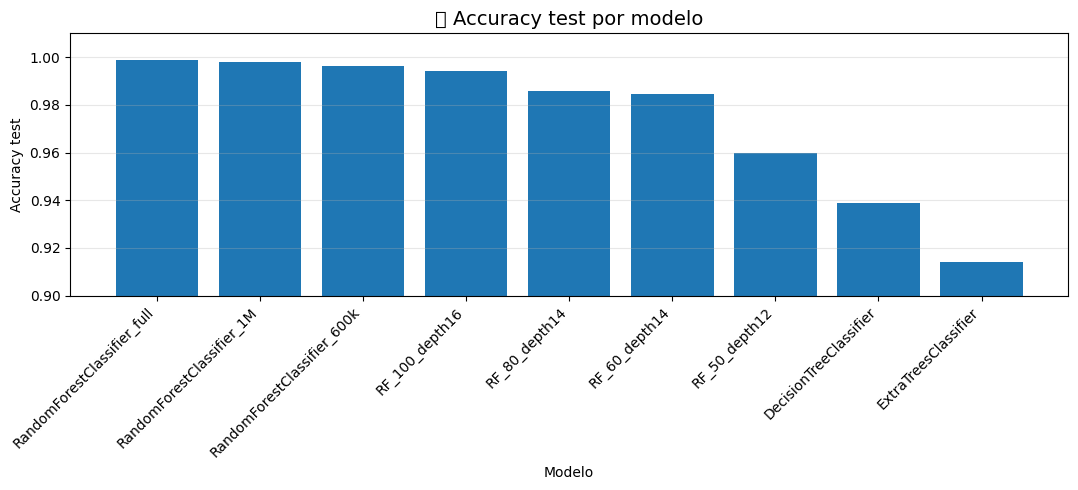

In [21]:
final_results = []

final_results.extend([
    {
        "grupo": "base_600k",
        "model": row["model"],
        "accuracy_train": row["accuracy_train"],
        "accuracy_test": row["accuracy_test"],
        "difference_train_test": row["difference_train_test"],
        "recall_malo": row["recall_malo"],
        "recall_regular": row["recall_regular"],
        "recall_bueno": row["recall_bueno"],
        "recall_excelente": row["recall_excelente"],
    }
    for _, row in base_results_df.iterrows()
])

final_results.append({
    "grupo": "modelo_1m",
    "model": rf_1m_summary.loc[0, "model"],
    "accuracy_train": rf_1m_summary.loc[0, "accuracy_train"],
    "accuracy_test": rf_1m_summary.loc[0, "accuracy_test"],
    "difference_train_test": rf_1m_summary.loc[0, "difference_train_test"],
    "recall_malo": rf_1m_summary.loc[0, "recall_malo"],
    "recall_regular": rf_1m_summary.loc[0, "recall_regular"],
    "recall_bueno": rf_1m_summary.loc[0, "recall_bueno"],
    "recall_excelente": rf_1m_summary.loc[0, "recall_excelente"],
})

if "rf_full_summary" in globals():
    final_results.append({
        "grupo": "modelo_full",
        "model": rf_full_summary.loc[0, "model"],
        "accuracy_train": rf_full_summary.loc[0, "accuracy_train"],
        "accuracy_test": rf_full_summary.loc[0, "accuracy_test"],
        "difference_train_test": rf_full_summary.loc[0, "difference_train_test"],
        "recall_malo": rf_full_summary.loc[0, "recall_malo"],
        "recall_regular": rf_full_summary.loc[0, "recall_regular"],
        "recall_bueno": rf_full_summary.loc[0, "recall_bueno"],
        "recall_excelente": rf_full_summary.loc[0, "recall_excelente"],
    })

final_results.extend([
    {
        "grupo": "modelo_ligero",
        "model": row["model"],
        "accuracy_train": row["accuracy_train"],
        "accuracy_test": row["accuracy_test"],
        "difference_train_test": row["difference_train_test"],
        "recall_malo": row["recall_malo"],
        "recall_regular": row["recall_regular"],
        "recall_bueno": row["recall_bueno"],
        "recall_excelente": row["recall_excelente"],
    }
    for _, row in light_results_df.iterrows()
])

final_results_df = (
    pd.DataFrame(final_results)
    .sort_values("accuracy_test", ascending=False)
    .reset_index(drop=True)
)

display(
    style_table(
        final_results_df.style.hide(axis="index").format({
            "accuracy_train": "{:.6f}",
            "accuracy_test": "{:.6f}",
            "difference_train_test": "{:.6f}",
            "recall_malo": "{:.6f}",
            "recall_regular": "{:.6f}",
            "recall_bueno": "{:.6f}",
            "recall_excelente": "{:.6f}",
        })
    )
)

plt.figure(figsize=(11, 5))
plt.bar(final_results_df["model"], final_results_df["accuracy_test"])
plt.title("📈 Accuracy test por modelo", fontsize=14)
plt.xlabel("Modelo")
plt.ylabel("Accuracy test")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.90, 1.01)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelo full es el mejor tecnicamente con 0.998867 de accuracy_test. El modelo 1M queda segundo con 0.997955 y el RandomForest_600k obtiene 0.996492. El modelo ligero RF_100_depth16 mantiene 0.994267 con mucho menor peso, por eso es viable para GitHub/demo.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Decision del modelo final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se seleccionara el modelo final considerando metricas, peso, velocidad de carga y facilidad de despliegue.
  </p>
</div>

In [24]:
selected_model_name = "RF_100_depth16"

selected_model_row = final_results_df[
    final_results_df["model"] == selected_model_name
].iloc[0]

modelo_final = pd.DataFrame([{
    "modelo_final": selected_model_name,
    "archivo_app": "models/light/salimoshoy_rf_100_depth16_compressed.pkl",
    "peso_mb": 28.49,
    "accuracy_test": selected_model_row["accuracy_test"],
    "recall_malo": selected_model_row["recall_malo"],
    "recall_regular": selected_model_row["recall_regular"],
    "motivo": "Mejor equilibrio entre rendimiento, peso y despliegue"
}])

display(
    style_table(
        modelo_final.style.hide(axis="index").format({
            "peso_mb": "{:.2f} MB",
            "accuracy_test": "{:.6f}",
            "recall_malo": "{:.6f}",
            "recall_regular": "{:.6f}",
        })
    )
)

modelo_final,archivo_app,peso_mb,accuracy_test,recall_malo,recall_regular,motivo
RF_100_depth16,models/light/salimoshoy_rf_100_depth16_compressed.pkl,28.49 MB,0.994267,0.992699,0.992456,"Mejor equilibrio entre rendimiento, peso y despliegue"


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se selecciona <span style="color:#D11A2A; font-weight:700;">RF_100_depth16</span> como modelo final para GitHub/demo. Su archivo es models/light/salimoshoy_rf_100_depth16_compressed.pkl, pesa 28.49 MB, alcanza 0.994267 de accuracy_test y mantiene recall alto en malo y regular.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Conexion del modelo con la app
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se resumira como el modelo final se conecta con la aplicacion web. La app no entrena modelos; carga el modelo ligero ya entrenado y lo usa para clasificar condiciones climaticas.
  </p>
</div>

In [26]:
conexion_app = pd.DataFrame([
    {
        "parte": "API Open-Meteo",
        "funcion": "Entrega el clima actualizado por ciudad y hora."
    },
    {
        "parte": "Preparacion de features",
        "funcion": "Organiza las variables en el mismo orden usado durante el entrenamiento."
    },
    {
        "parte": "Modelo ML",
        "funcion": "Clasifica las condiciones como malo, regular, bueno o excelente."
    },

])

display(
    style_table(
        conexion_app.style.hide(axis="index")
    )
)

parte,funcion
API Open-Meteo,Entrega el clima actualizado por ciudad y hora.
Preparacion de features,Organiza las variables en el mismo orden usado durante el entrenamiento.
Modelo ML,"Clasifica las condiciones como malo, regular, bueno o excelente."


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    La app combina tres partes: Open-Meteo entrega el clima actualizado, las features se preparan en el mismo orden del entrenamiento y el modelo clasifica la recomendacion. El modelo no predice el clima; clasifica si las condiciones recibidas son convenientes para la actividad.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Conclusion final del modelado
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #38bdf8;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se resume el resultado final del proceso de entrenamiento y seleccion del modelo.
  </p>
</div>

In [28]:
conclusion_final = pd.DataFrame([
    {
        "punto": "Dataset final",
        "resultado": "3,054,400 registros, 200 ciudades, 6 meses estrategicos y 6 actividades oficiales."
    },
    {
        "punto": "EDA",
        "resultado": "No se detectaron nulos y las clases de recommendation tuvieron representacion suficiente."
    },
    {
        "punto": "Modelos probados",
        "resultado": "Se compararon modelos base, modelos grandes y modelos ligeros optimizados para GitHub/demo."
    },
    {
        "punto": "Modelo elegido",
        "resultado": "RF_100_depth16 comprimido, con accuracy test alta y buen recall en malo y regular."
    },
    {
        "punto": "Uso en la app",
        "resultado": "La app carga el modelo ligero de forma eficiente."
    }
])

display(
    style_table(
        conclusion_final.style.hide(axis="index")
    )
)

punto,resultado
Dataset final,"3,054,400 registros, 200 ciudades, 6 meses estrategicos y 6 actividades oficiales."
EDA,No se detectaron nulos y las clases de recommendation tuvieron representacion suficiente.
Modelos probados,"Se compararon modelos base, modelos grandes y modelos ligeros optimizados para GitHub/demo."
Modelo elegido,"RF_100_depth16 comprimido, con accuracy test alta y buen recall en malo y regular."
Uso en la app,La app carga el modelo ligero de forma eficiente.


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    El modelado queda cerrado con evidencia ejecutada. Se valido un dataset de 3,054,400 registros, se entrenaron modelos base, modelos grandes y modelos ligeros, y se eligio RF_100_depth16 por su equilibrio entre rendimiento y despliegue. La app final usa el modelo ligero para mantener una demo funcional, rapida y compatible con GitHub.
  </p>
</div>